In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("📊 ETHIOPIA FINANCIAL INCLUSION - TASK 2: EDA")
print("="*70)
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("="*70)

# Load the enriched dataset
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')

print(f"\n✅ Loaded enriched dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Separate by record type
observations = df[df['record_type'] == 'observation']
events = df[df['record_type'] == 'event']
targets = df[df['record_type'] == 'target']
impacts = df[df['record_type'] == 'impact_link']

print(f"\n📋 Record breakdown:")
print(f"   Observations: {len(observations)}")
print(f"   Events: {len(events)}")
print(f"   Targets: {len(targets)}")
print(f"   Impact links: {len(impacts)}")

📊 ETHIOPIA FINANCIAL INCLUSION - TASK 2: EDA
Date: 2026-07-21 18:33

✅ Loaded enriched dataset: 45 rows, 34 columns

📋 Record breakdown:
   Observations: 31
   Events: 10
   Targets: 3
   Impact links: 1


In [2]:
print("\n" + "="*70)
print("📊 DATASET OVERVIEW")
print("="*70)

print(f"\n📁 Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📅 Date range:")
if len(observations) > 0:
    dates = pd.to_datetime(observations['observation_date'])
    print(f"   Earliest: {dates.min().strftime('%Y-%m-%d')}")
    print(f"   Latest: {dates.max().strftime('%Y-%m-%d')}")
    print(f"   Unique years: {sorted(dates.dt.year.unique())}")

print(f"\n📊 Indicators by pillar:")
for pillar in df['pillar'].unique():
    if pd.notna(pillar):
        pillar_data = df[df['pillar'] == pillar]
        indicators = pillar_data['indicator_code'].unique()
        print(f"   {pillar}: {len(indicators)} indicators")

print(f"\n🔗 Impact links: {len(impacts)}")
if len(impacts) > 0:
    print(f"   Magnitude range: {impacts['impact_magnitude'].min():.2f} to {impacts['impact_magnitude'].max():.2f}")
    print(f"   Average lag: {impacts['lag_months'].mean():.1f} months")


📊 DATASET OVERVIEW

📁 Shape: 45 rows, 34 columns

📅 Date range:
   Earliest: 2014-12-31
   Latest: 2025-12-31
   Unique years: [np.int32(2014), np.int32(2015), np.int32(2017), np.int32(2021), np.int32(2023), np.int32(2024), np.int32(2025)]

📊 Indicators by pillar:
   ACCESS: 6 indicators
   USAGE: 10 indicators
   AFFORDABILITY: 1 indicators
   GENDER: 3 indicators

🔗 Impact links: 1
   Magnitude range: 0.05 to 0.05
   Average lag: 12.0 months


In [3]:
print("\n" + "="*70)
print("📊 DATA QUALITY ASSESSMENT")
print("="*70)

# Confidence levels
print("\n📊 Confidence levels:")
conf_counts = df['confidence'].value_counts()
for conf, count in conf_counts.items():
    pct = (count / len(df)) * 100
    print(f"   {conf}: {count} ({pct:.1f}%)")

# Source types
print("\n📚 Source types:")
for src, count in df['source_type'].value_counts().items():
    print(f"   {src}: {count}")

# Missing values
print("\n📊 Missing values (top 10):")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col, count in missing.head(10).items():
    pct = (count / len(df)) * 100
    print(f"   {col}: {count} ({pct:.1f}%)")


📊 DATA QUALITY ASSESSMENT

📊 Confidence levels:
   high: 41 (91.1%)
   medium: 4 (8.9%)

📚 Source types:
   operator: 15
   survey: 10
   regulator: 7
   research: 5
   policy: 3
   calculated: 2
   news: 2

📊 Missing values (top 10):
   region: 45 (100.0%)
   lag_months: 44 (97.8%)
   related_indicator: 44 (97.8%)
   relationship_type: 44 (97.8%)
   impact_direction: 44 (97.8%)
   evidence_basis: 44 (97.8%)
   impact_magnitude: 44 (97.8%)
   impact_estimate: 44 (97.8%)
   notes: 43 (95.6%)
   category: 35 (77.8%)



📊 ACCESS ANALYSIS - ACCOUNT OWNERSHIP

📈 Account Ownership Data Points:
   2014: 22.0% (Global Findex 2014)
   2015: 22.0% (Estimated from trend)
   2017: 35.0% (Global Findex 2017)
   2021: 46.0% (Global Findex 2021)
   2021: 56.0% (Global Findex 2021)
   2021: 36.0% (Global Findex 2021)
   2024: 49.0% (Global Findex 2024)

📊 Growth Rates:
   2014→2015: +0.0pp (0.0 pp/year)
   2015→2017: +13.0pp (6.5 pp/year)
   2017→2021: +11.0pp (2.8 pp/year)
   2021→2021: +10.0pp (inf pp/year)
   2021→2021: +-20.0pp (-inf pp/year)
   2021→2024: +13.0pp (4.3 pp/year)


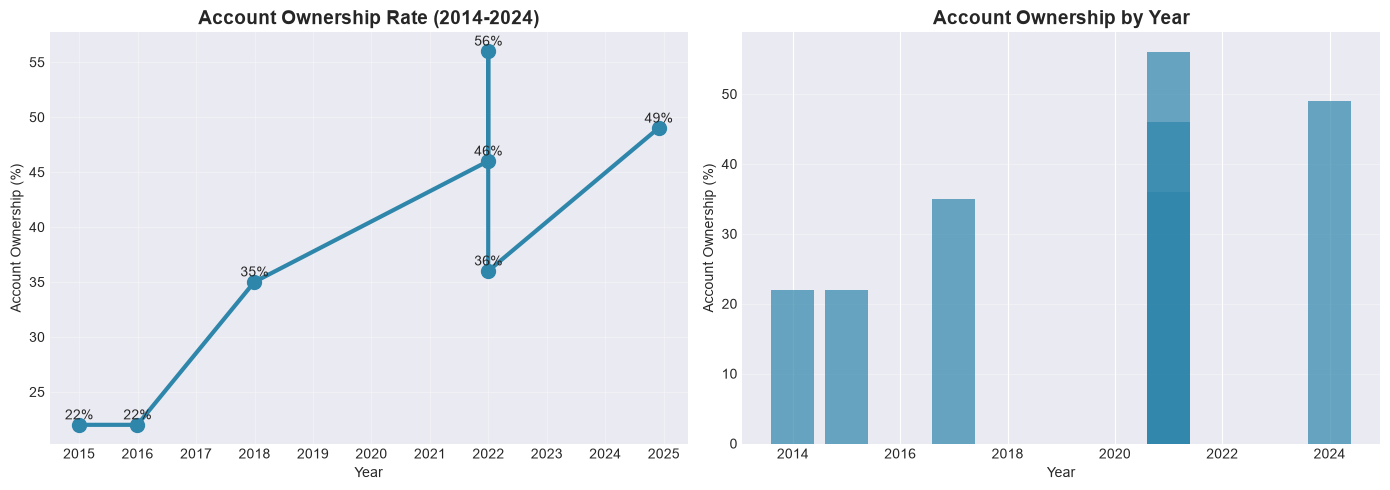


✅ Saved to: reports/figures/account_ownership_trend.png


In [4]:
print("\n" + "="*70)
print("📊 ACCESS ANALYSIS - ACCOUNT OWNERSHIP")
print("="*70)

# Get account ownership data
acc_data = df[(df['record_type'] == 'observation') & 
              (df['indicator_code'] == 'ACC_OWNERSHIP')].copy()

if len(acc_data) > 0:
    # Sort by date
    acc_data['date'] = pd.to_datetime(acc_data['observation_date'])
    acc_data = acc_data.sort_values('date')
    
    print("\n📈 Account Ownership Data Points:")
    for _, row in acc_data.iterrows():
        print(f"   {row['date'].year}: {row['value_numeric']:.1f}% ({row['source_name']})")
    
    # Calculate growth rates
    print("\n📊 Growth Rates:")
    for i in range(1, len(acc_data)):
        prev = acc_data.iloc[i-1]
        curr = acc_data.iloc[i]
        years = (curr['date'].year - prev['date'].year)
        growth = curr['value_numeric'] - prev['value_numeric']
        annual_growth = growth / years
        print(f"   {prev['date'].year}→{curr['date'].year}: +{growth:.1f}pp ({annual_growth:.1f} pp/year)")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Line plot
    axes[0].plot(acc_data['date'], acc_data['value_numeric'], 
                 marker='o', linewidth=3, markersize=10, color='#2E86AB')
    axes[0].set_title('Account Ownership Rate (2014-2024)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Account Ownership (%)')
    axes[0].grid(True, alpha=0.3)
    
    # Add labels
    for _, row in acc_data.iterrows():
        axes[0].text(row['date'], row['value_numeric'] + 0.5, 
                    f"{row['value_numeric']:.0f}%", ha='center', fontsize=10)
    
    # Bar plot
    axes[1].bar(acc_data['date'].dt.year, acc_data['value_numeric'], 
                color='#2E86AB', alpha=0.7)
    axes[1].set_title('Account Ownership by Year', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Account Ownership (%)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/account_ownership_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/account_ownership_trend.png")

In [5]:
print("\n" + "="*70)
print("📊 GENDER GAP ANALYSIS")
print("="*70)

# Check if we have gender data
gender_data = df[(df['record_type'] == 'observation') & 
                 (df['indicator_code'].str.contains('GENDER|GAP', na=False))]

if len(gender_data) > 0:
    print(f"\n📊 Gender-related indicators found:")
    for ind in gender_data['indicator_code'].unique():
        print(f"   - {ind}")
    
    # Look for specific gender indicators
    gender_gap = df[(df['record_type'] == 'observation') & 
                    (df['indicator_code'] == 'GEN_GAP_ACC')]
    
    if len(gender_gap) > 0:
        print("\n📈 Gender Gap in Account Ownership:")
        gender_gap_sorted = gender_gap.sort_values('observation_date')
        for _, row in gender_gap_sorted.iterrows():
            date = pd.to_datetime(row['observation_date'])
            print(f"   {date.year}: {row['value_numeric']:.1f}% gap")
    else:
        print("\n⚠️ No specific gender gap data found")
else:
    print("\n⚠️ No gender-specific data found in the dataset")


📊 GENDER GAP ANALYSIS

📊 Gender-related indicators found:
   - GEN_GAP_ACC
   - GEN_GAP_MOBILE

📈 Gender Gap in Account Ownership:
   2021: 20.0% gap
   2024: 18.0% gap



📊 MOBILE MONEY ANALYSIS

📈 Mobile Money Account Data:
   2021: 4.70% (Global Findex 2021)
   2024: 9.45% (Global Findex 2024)


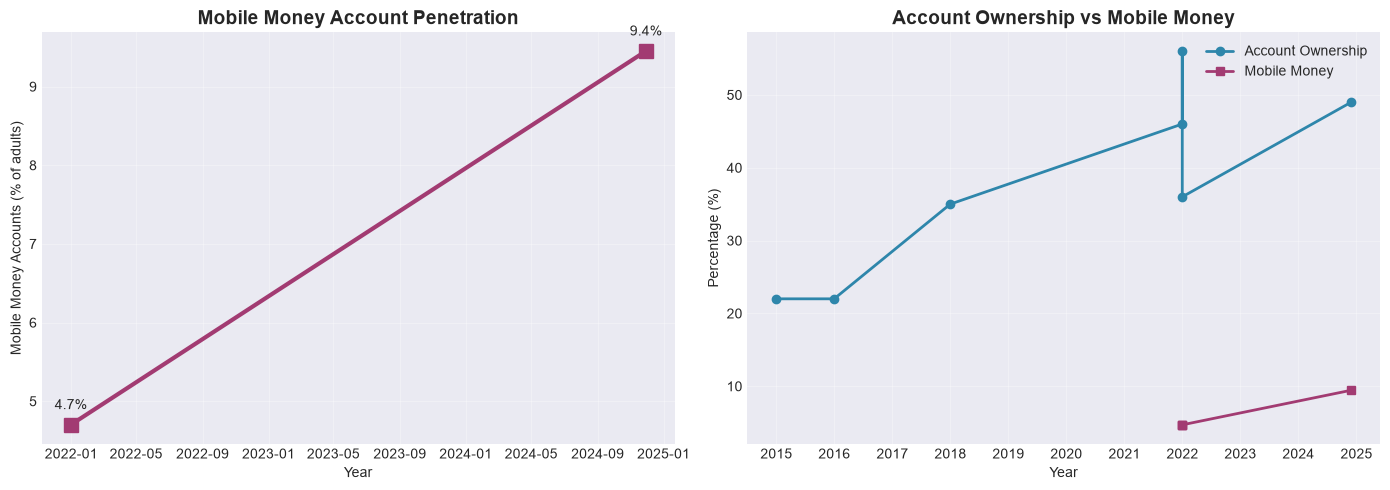


✅ Saved to: reports/figures/mobile_money_analysis.png


In [6]:
print("\n" + "="*70)
print("📊 MOBILE MONEY ANALYSIS")
print("="*70)

# Get mobile money data
mm_data = df[(df['record_type'] == 'observation') & 
             (df['indicator_code'] == 'ACC_MM_ACCOUNT')].copy()

if len(mm_data) > 0:
    mm_data['date'] = pd.to_datetime(mm_data['observation_date'])
    mm_data = mm_data.sort_values('date')
    
    print("\n📈 Mobile Money Account Data:")
    for _, row in mm_data.iterrows():
        print(f"   {row['date'].year}: {row['value_numeric']:.2f}% ({row['source_name']})")
    
    # Plot mobile money vs account ownership
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mobile money trend
    axes[0].plot(mm_data['date'], mm_data['value_numeric'], 
                 marker='s', linewidth=3, markersize=10, color='#A23B72')
    axes[0].set_title('Mobile Money Account Penetration', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Mobile Money Accounts (% of adults)')
    axes[0].grid(True, alpha=0.3)
    
    for _, row in mm_data.iterrows():
        axes[0].text(row['date'], row['value_numeric'] + 0.2, 
                    f"{row['value_numeric']:.1f}%", ha='center', fontsize=10)
    
    # Compare mobile money vs account ownership
    # Merge the two datasets
    if len(acc_data) > 0:
        merged = pd.merge(acc_data[['date', 'value_numeric']], 
                         mm_data[['date', 'value_numeric']], 
                         on='date', suffixes=('_acc', '_mm'), how='outer')
        merged = merged.sort_values('date')
        
        axes[1].plot(merged['date'], merged['value_numeric_acc'], 
                     marker='o', linewidth=2, label='Account Ownership', color='#2E86AB')
        axes[1].plot(merged['date'], merged['value_numeric_mm'], 
                     marker='s', linewidth=2, label='Mobile Money', color='#A23B72')
        axes[1].set_title('Account Ownership vs Mobile Money', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Percentage (%)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/mobile_money_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/mobile_money_analysis.png")
else:
    print("⚠️ No mobile money data found")


📊 USAGE ANALYSIS - DIGITAL PAYMENTS

📊 Usage Indicators Found:
   USG_P2P_COUNT: 2 data points
   USG_P2P_VALUE: 1 data points
   USG_ATM_COUNT: 1 data points
   USG_TELEBIRR_USERS: 1 data points
   USG_MPESA_USERS: 1 data points

📈 USG_P2P_COUNT:
   2024: 49.7M (EthSwitch Annual Report)
   2025: 128.3M (EthSwitch Annual Report)

📈 USG_P2P_VALUE:
   2025: 577700.0M (EthSwitch Annual Report)

📈 USG_ATM_COUNT:
   2025: 119.3M (EthSwitch Annual Report)

📈 USG_TELEBIRR_USERS:
   2025: 54.8M (Ethio Telecom Report)

📈 USG_MPESA_USERS:
   2024: 10.8M (Safaricom Results)

📊 Latest values for plotting:
   USG_P2P_COUNT: 128.3M
   USG_P2P_VALUE: 577700.0M
   USG_ATM_COUNT: 119.3M
   USG_TELEBIRR_USERS: 54.8M
   USG_MPESA_USERS: 10.8M


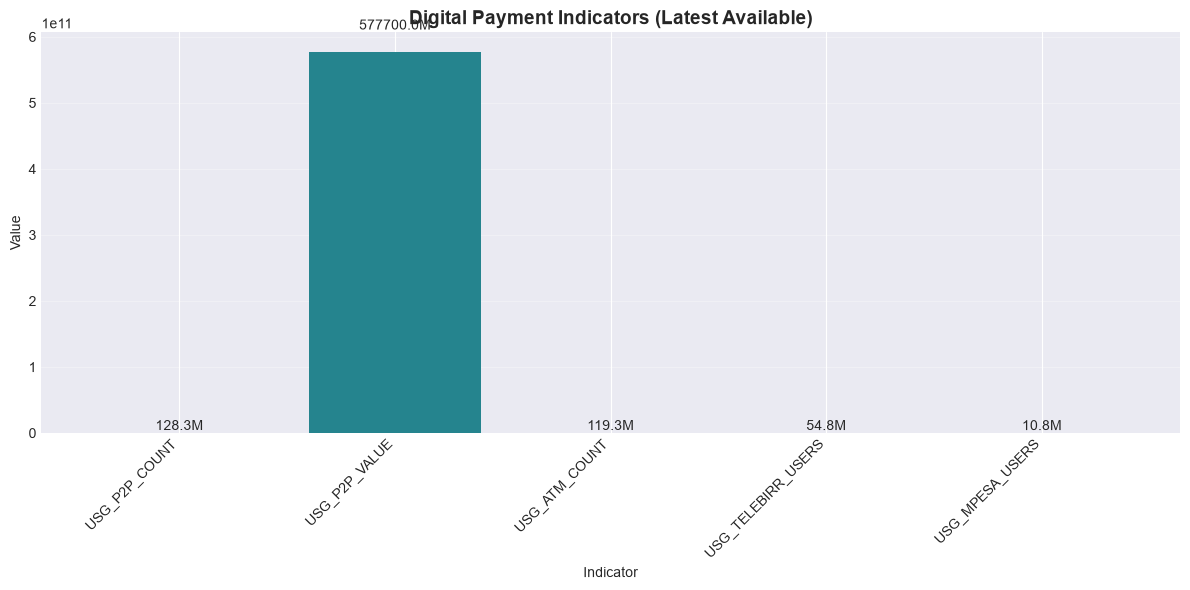


✅ Saved to: reports/figures/usage_indicators.png


In [9]:
print("\n" + "="*70)
print("📊 USAGE ANALYSIS - DIGITAL PAYMENTS")
print("="*70)

# Get usage indicators
usage_indicators = ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 
                    'USG_TELEBIRR_USERS', 'USG_MPESA_USERS']

usage_data = df[(df['record_type'] == 'observation') & 
                (df['indicator_code'].isin(usage_indicators))]

if len(usage_data) > 0:
    print(f"\n📊 Usage Indicators Found:")
    available_indicators = usage_data['indicator_code'].unique()
    for ind in available_indicators:
        data = usage_data[usage_data['indicator_code'] == ind]
        print(f"   {ind}: {len(data)} data points")
    
    # Show data for each indicator
    for ind in available_indicators:
        data = usage_data[usage_data['indicator_code'] == ind].sort_values('observation_date')
        print(f"\n📈 {ind}:")
        for _, row in data.iterrows():
            date = pd.to_datetime(row['observation_date'])
            value = row['value_numeric']
            source = row['source_name'] if pd.notna(row['source_name']) else 'Unknown'
            # Format large numbers
            if value > 1000000:
                print(f"   {date.year}: {value/1000000:.1f}M ({source})")
            elif value > 1000:
                print(f"   {date.year}: {value/1000:.1f}K ({source})")
            else:
                print(f"   {date.year}: {value:.0f} ({source})")
    
    # Get the latest value for each indicator - FIXED APPROACH
    latest_data_list = []
    for ind in available_indicators:
        ind_data = usage_data[usage_data['indicator_code'] == ind]
        latest_row = ind_data.loc[ind_data['observation_date'].idxmax()]
        latest_data_list.append({
            'indicator_code': ind,
            'value_numeric': latest_row['value_numeric'],
            'observation_date': latest_row['observation_date']
        })
    
    latest_df = pd.DataFrame(latest_data_list)
    
    print(f"\n📊 Latest values for plotting:")
    for _, row in latest_df.iterrows():
        if row['value_numeric'] > 1000000:
            print(f"   {row['indicator_code']}: {row['value_numeric']/1000000:.1f}M")
        elif row['value_numeric'] > 1000:
            print(f"   {row['indicator_code']}: {row['value_numeric']/1000:.1f}K")
        else:
            print(f"   {row['indicator_code']}: {row['value_numeric']:.0f}")
    
    # Create the bar chart
    plt.figure(figsize=(12, 6))
    
    # Create bars with different colors
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(latest_df)))
    bars = plt.bar(latest_df['indicator_code'], latest_df['value_numeric'], color=colors)
    
    plt.title('Digital Payment Indicators (Latest Available)', fontsize=14, fontweight='bold')
    plt.xlabel('Indicator')
    plt.ylabel('Value')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels with formatting
    for bar, row in zip(bars, latest_df.iterrows()):
        value = row[1]['value_numeric']
        if value > 1000000:  # If value is in millions
            label = f'{value/1000000:.1f}M'
        elif value > 1000:
            label = f'{value/1000:.1f}K'
        else:
            label = f'{value:.0f}'
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05 * bar.get_height(),
                label, ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/usage_indicators.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/usage_indicators.png")
else:
    print("⚠️ No usage data found")


📊 CORRELATION ANALYSIS

📊 Available observations: 31
   Pivot shape: 14 dates, 19 indicators


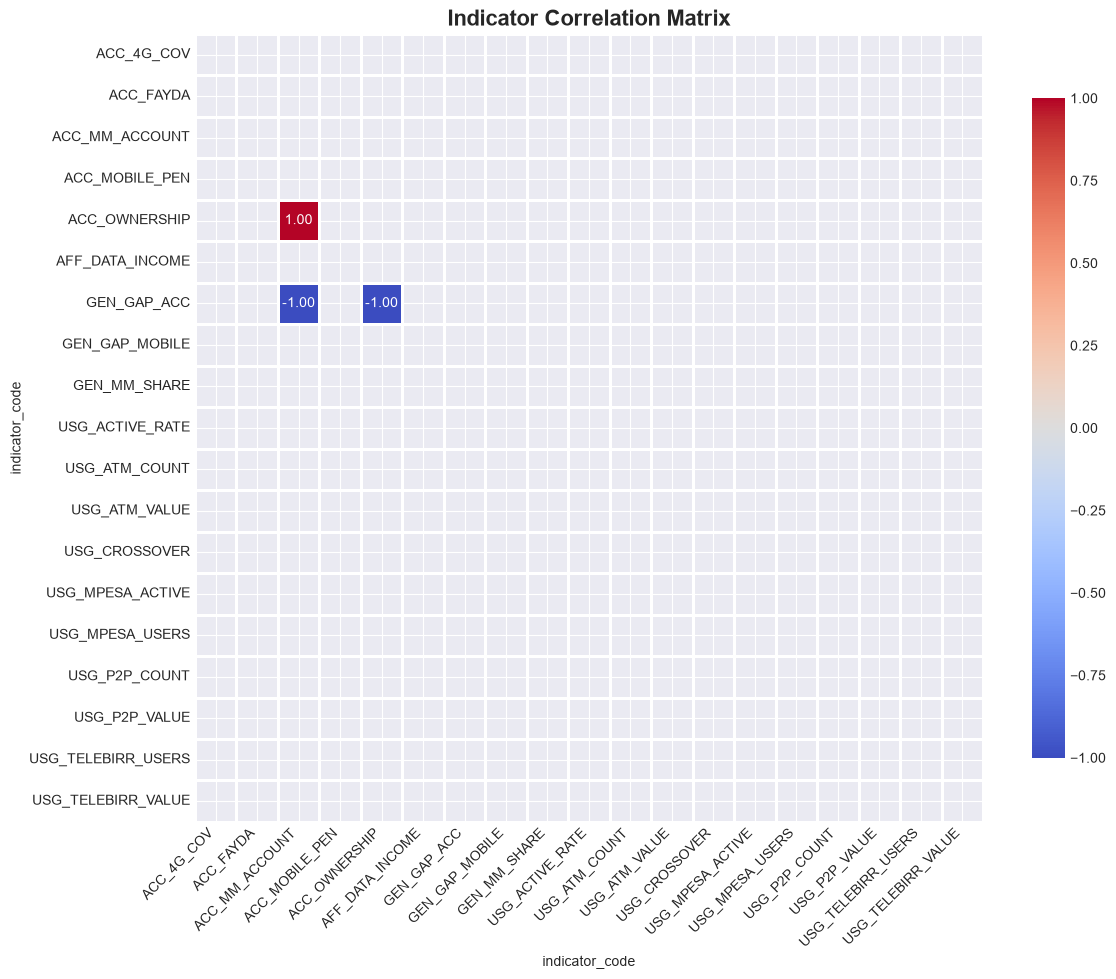


✅ Saved to: reports/figures/correlation_matrix.png

📈 Strongest correlations with Account Ownership:
   ACC_MM_ACCOUNT: 1.00
   GEN_GAP_ACC: -1.00

📈 Strongest correlations with Mobile Money:
   ACC_OWNERSHIP: 1.00
   GEN_GAP_ACC: -1.00


In [10]:
print("\n" + "="*70)
print("📊 CORRELATION ANALYSIS")
print("="*70)

# Create a pivot table for correlation analysis
obs_data = df[df['record_type'] == 'observation'].copy()

# Check if we have enough data
if len(obs_data) > 0:
    print(f"\n📊 Available observations: {len(obs_data)}")
    
    # Create pivot table
    obs_pivot = obs_data.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric',
        aggfunc='mean'
    )
    
    print(f"   Pivot shape: {obs_pivot.shape[0]} dates, {obs_pivot.shape[1]} indicators")
    
    if obs_pivot.shape[1] > 1 and obs_pivot.shape[0] > 2:
        # Calculate correlation matrix
        corr_matrix = obs_pivot.corr()
        
        # Plot correlation heatmap
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('Indicator Correlation Matrix', fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✅ Saved to: reports/figures/correlation_matrix.png")
        
        # Find strongest correlations
        if 'ACC_OWNERSHIP' in corr_matrix.columns:
            print("\n📈 Strongest correlations with Account Ownership:")
            correlations = corr_matrix['ACC_OWNERSHIP'].drop('ACC_OWNERSHIP', errors='ignore')
            correlations = correlations.sort_values(ascending=False)
            for ind, corr in correlations.head(5).items():
                if not pd.isna(corr):
                    print(f"   {ind}: {corr:.2f}")
        
        if 'ACC_MM_ACCOUNT' in corr_matrix.columns:
            print("\n📈 Strongest correlations with Mobile Money:")
            correlations = corr_matrix['ACC_MM_ACCOUNT'].drop('ACC_MM_ACCOUNT', errors='ignore')
            correlations = correlations.sort_values(ascending=False)
            for ind, corr in correlations.head(5).items():
                if not pd.isna(corr):
                    print(f"   {ind}: {corr:.2f}")
    else:
        print("\n⚠️ Not enough data for correlation analysis")
        print(f"   Need at least 3 indicators and 3 dates")
        print(f"   Have: {obs_pivot.shape[1]} indicators, {obs_pivot.shape[0]} dates")
        
        # Show what we have
        print("\n📊 Available indicators:")
        for col in obs_pivot.columns:
            count = obs_pivot[col].count()
            print(f"   {col}: {count} data points")
else:
    print("⚠️ No observation data found")

In [11]:
def format_number(num):
    """Format large numbers for display"""
    if pd.isna(num):
        return "N/A"
    if num >= 1000000:
        return f"{num/1000000:.1f}M"
    elif num >= 1000:
        return f"{num/1000:.1f}K"
    else:
        return f"{num:.0f}"


📊 INFRASTRUCTURE AND ENABLERS

📊 Infrastructure Indicators Found:
   ACC_4G_COV: 2 data points
   ACC_MOBILE_PEN: 1 data points
   ACC_FAYDA: 3 data points

📈 ACC_4G_COV:
   2023: 38 (Ethio Telecom LEAD Report)
   2025: 71 (Ethio Telecom LEAD Report)

📈 ACC_MOBILE_PEN:
   2025: 61 (DataReportal Digital 2026)

📈 ACC_FAYDA:
   2024: 8000000 (Fayda Official)
   2025: 12000000 (World Bank)
   2025: 15000000 (ID4Africa Conference)


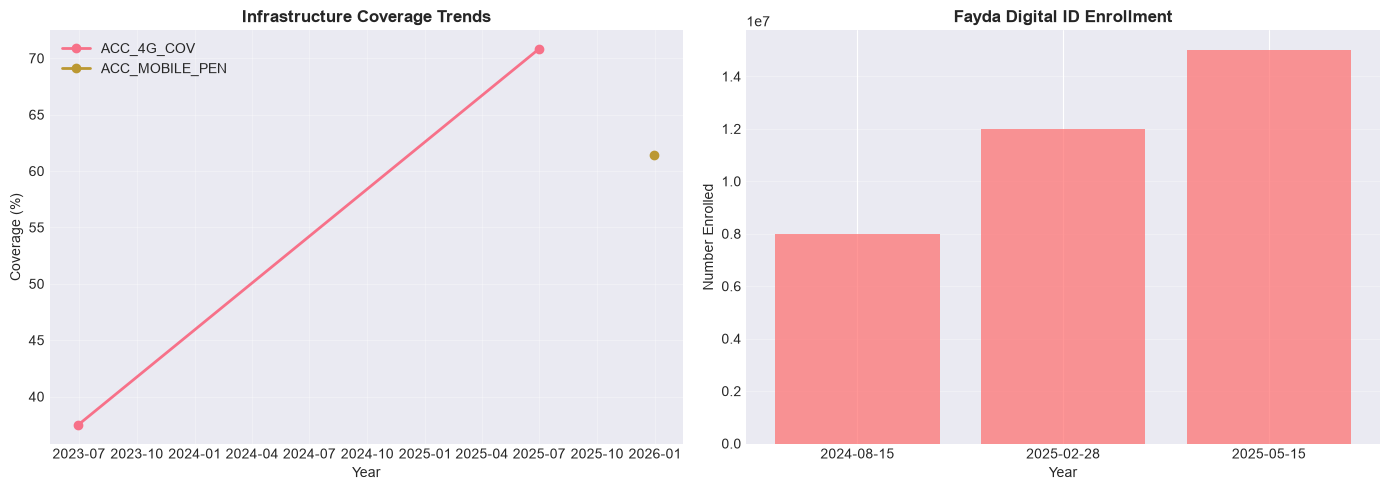


✅ Saved to: reports/figures/infrastructure_trends.png


In [12]:
print("\n" + "="*70)
print("📊 INFRASTRUCTURE AND ENABLERS")
print("="*70)

# Get infrastructure indicators
infra_indicators = ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA']

infra_data = df[(df['record_type'] == 'observation') & 
                (df['indicator_code'].isin(infra_indicators))]

if len(infra_data) > 0:
    print("\n📊 Infrastructure Indicators Found:")
    for ind in infra_data['indicator_code'].unique():
        data = infra_data[infra_data['indicator_code'] == ind]
        print(f"   {ind}: {len(data)} data points")
    
    # Show data
    for ind in infra_data['indicator_code'].unique():
        data = infra_data[infra_data['indicator_code'] == ind].sort_values('observation_date')
        print(f"\n📈 {ind}:")
        for _, row in data.iterrows():
            date = pd.to_datetime(row['observation_date'])
            print(f"   {date.year}: {row['value_numeric']:.0f} ({row['source_name']})")
    
    # Plot infrastructure trends
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Filter data
    for ind in infra_data['indicator_code'].unique():
        data = infra_data[infra_data['indicator_code'] == ind].sort_values('observation_date')
        
        # Plot on first axis if it's a percentage or coverage
        if ind in ['ACC_4G_COV', 'ACC_MOBILE_PEN']:
            axes[0].plot(pd.to_datetime(data['observation_date']), 
                        data['value_numeric'], 
                        marker='o', linewidth=2, label=ind)
    
    axes[0].set_title('Infrastructure Coverage Trends', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Coverage (%)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Fayda (Digital ID) data
    fayda_data = infra_data[infra_data['indicator_code'] == 'ACC_FAYDA']
    if len(fayda_data) > 0:
        axes[1].bar(fayda_data['observation_date'], fayda_data['value_numeric'], 
                   color='#FF6B6B', alpha=0.7)
        axes[1].set_title('Fayda Digital ID Enrollment', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Number Enrolled')
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/infrastructure_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/infrastructure_trends.png")
else:
    print("⚠️ No infrastructure data found")


📊 EVENT TIMELINE AND VISUAL ANALYSIS

📅 Event Timeline:
   2021-05-17 - PRODUCT_LAUNCH: Telebirr Launch
   2021-09-01 - POLICY: NFIS-II Strategy Launch
   2022-08-01 - MARKET_ENTRY: Safaricom Ethiopia Commercial Launch
   2023-08-01 - PRODUCT_LAUNCH: M-Pesa Ethiopia Launch
   2024-01-01 - INFRASTRUCTURE: Fayda Digital ID Program Rollout
   2024-07-29 - POLICY: Foreign Exchange Liberalization
   2024-10-01 - MILESTONE: P2P Transaction Count Surpasses ATM
   2025-10-27 - PARTNERSHIP: M-Pesa EthSwitch Integration
   2025-12-15 - PRICING: Safaricom Ethiopia Price Increase
   2025-12-18 - INFRASTRUCTURE: EthioPay Instant Payment System Launch


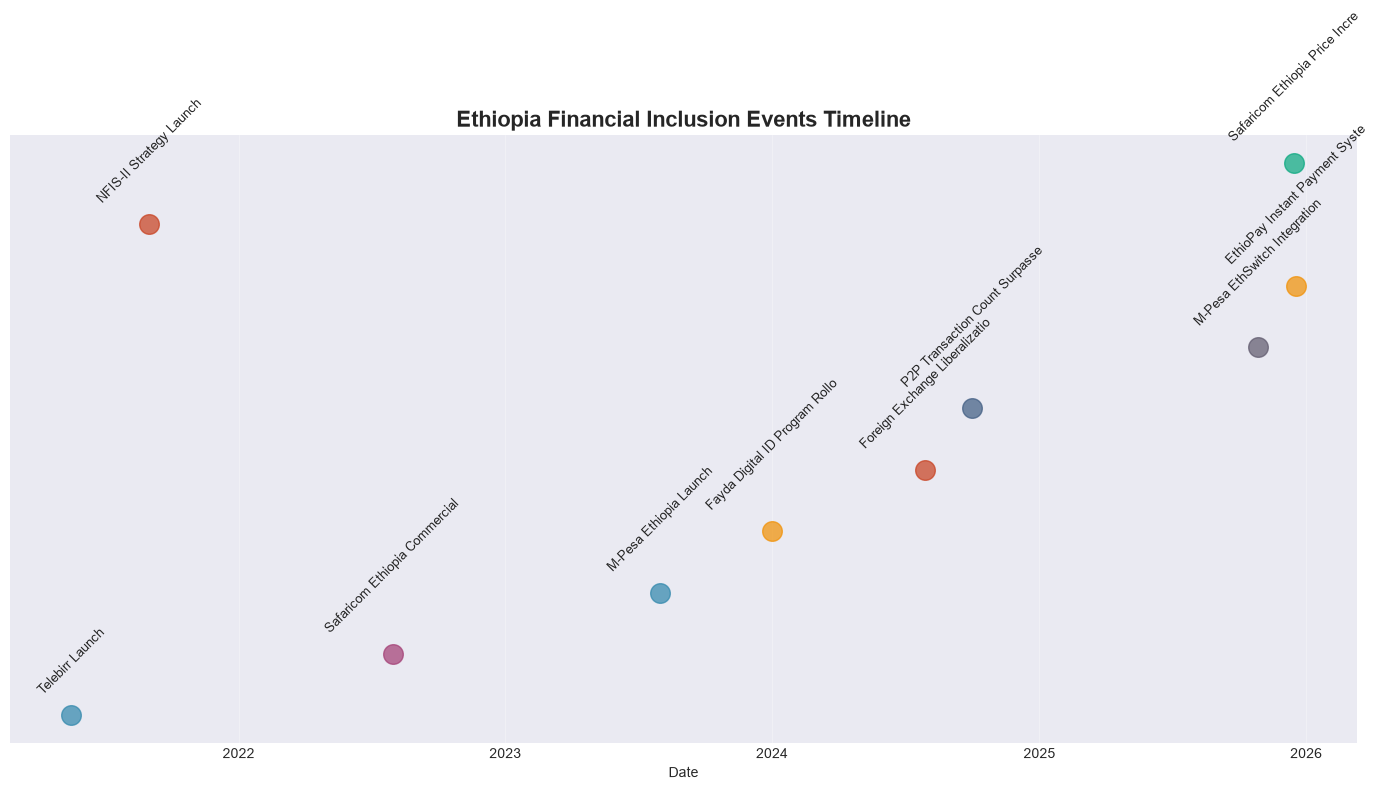


✅ Saved to: reports/figures/event_timeline.png


In [13]:
print("\n" + "="*70)
print("📊 EVENT TIMELINE AND VISUAL ANALYSIS")
print("="*70)

if len(events) > 0:
    # Prepare events for timeline
    events_timeline = events.copy()
    events_timeline['date'] = pd.to_datetime(events_timeline['observation_date'])
    events_timeline = events_timeline.sort_values('date')
    
    print("\n📅 Event Timeline:")
    for _, row in events_timeline.iterrows():
        category = row['category'] if pd.notna(row['category']) else 'other'
        indicator = row['indicator'] if pd.notna(row['indicator']) else 'Unknown'
        date = row['date'].strftime('%Y-%m-%d')
        print(f"   {date} - {category.upper()}: {indicator}")
    
    # Create a timeline visualization
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot event categories as colored markers
    category_colors = {
        'product_launch': '#2E86AB',
        'market_entry': '#A23B72',
        'infrastructure': '#F18F01',
        'policy': '#C73E1D',
        'milestone': '#3D5A80',
        'partnership': '#5D576B',
        'pricing': '#06A77D'
    }
    
    for idx, row in events_timeline.iterrows():
        cat = row['category'] if pd.notna(row['category']) else 'other'
        color = category_colors.get(cat, '#808080')
        ax.scatter(row['date'], idx, s=200, color=color, alpha=0.7, 
                   label=cat if idx == 0 else "")
        ax.text(row['date'], idx + 0.3, row['indicator'][:30], 
                rotation=45, ha='center', va='bottom', fontsize=9)
    
    ax.set_title('Ethiopia Financial Inclusion Events Timeline', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.savefig('../reports/figures/event_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/event_timeline.png")

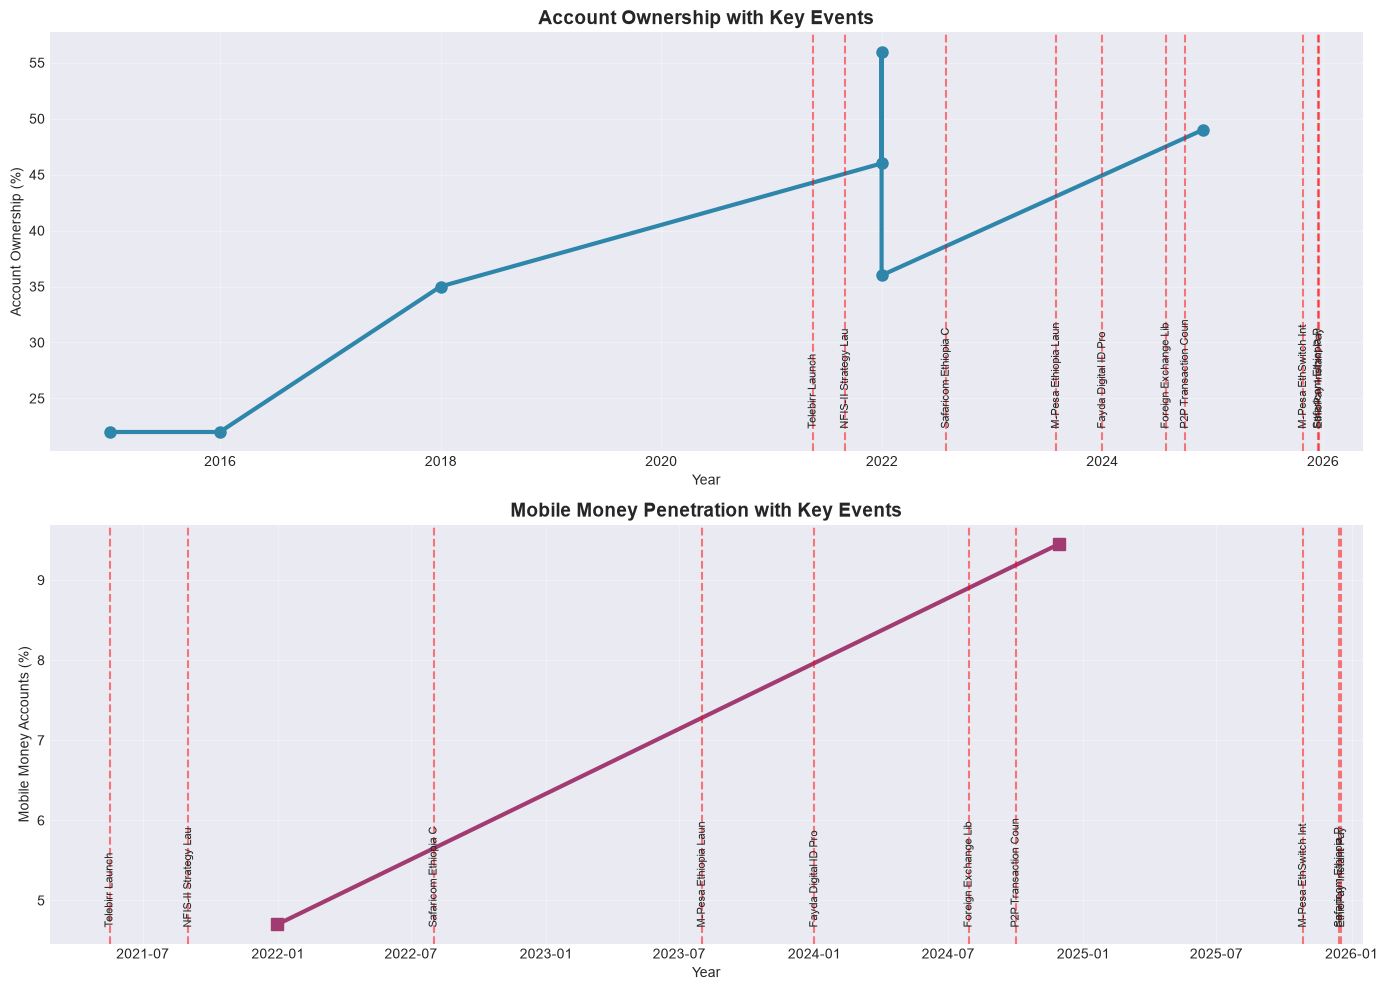


✅ Saved to: reports/figures/events_and_indicators.png


In [14]:
# Create a combined view of events and indicators
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Account Ownership with events
acc_data = df[(df['record_type'] == 'observation') & 
              (df['indicator_code'] == 'ACC_OWNERSHIP')].copy()
acc_data['date'] = pd.to_datetime(acc_data['observation_date'])
acc_data = acc_data.sort_values('date')

if len(acc_data) > 0:
    axes[0].plot(acc_data['date'], acc_data['value_numeric'], 
                marker='o', linewidth=3, markersize=8, color='#2E86AB')
    axes[0].set_title('Account Ownership with Key Events', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Account Ownership (%)')
    axes[0].grid(True, alpha=0.3)
    
    # Add event markers
    for _, event in events_timeline.iterrows():
        if event['date'].year >= 2014:
            ax = axes[0]
            ax.axvline(x=event['date'], color='red', linestyle='--', alpha=0.5)
            label = event['indicator'][:20] if pd.notna(event['indicator']) else event['category']
            ax.text(event['date'], ax.get_ylim()[0] + 2, label, 
                   rotation=90, ha='center', va='bottom', fontsize=8)

# Plot 2: Mobile Money with events
mm_data = df[(df['record_type'] == 'observation') & 
             (df['indicator_code'] == 'ACC_MM_ACCOUNT')].copy()
if len(mm_data) > 0:
    mm_data['date'] = pd.to_datetime(mm_data['observation_date'])
    mm_data = mm_data.sort_values('date')
    
    axes[1].plot(mm_data['date'], mm_data['value_numeric'], 
                marker='s', linewidth=3, markersize=8, color='#A23B72')
    axes[1].set_title('Mobile Money Penetration with Key Events', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Mobile Money Accounts (%)')
    axes[1].grid(True, alpha=0.3)
    
    # Add event markers
    for _, event in events_timeline.iterrows():
        if event['date'].year >= 2020:
            ax = axes[1]
            ax.axvline(x=event['date'], color='red', linestyle='--', alpha=0.5)
            label = event['indicator'][:20] if pd.notna(event['indicator']) else event['category']
            ax.text(event['date'], ax.get_ylim()[0] + 0.2, label, 
                   rotation=90, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/events_and_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved to: reports/figures/events_and_indicators.png")


📊 CORRELATION ANALYSIS

📊 Data for correlation: 14 observations, 19 indicators


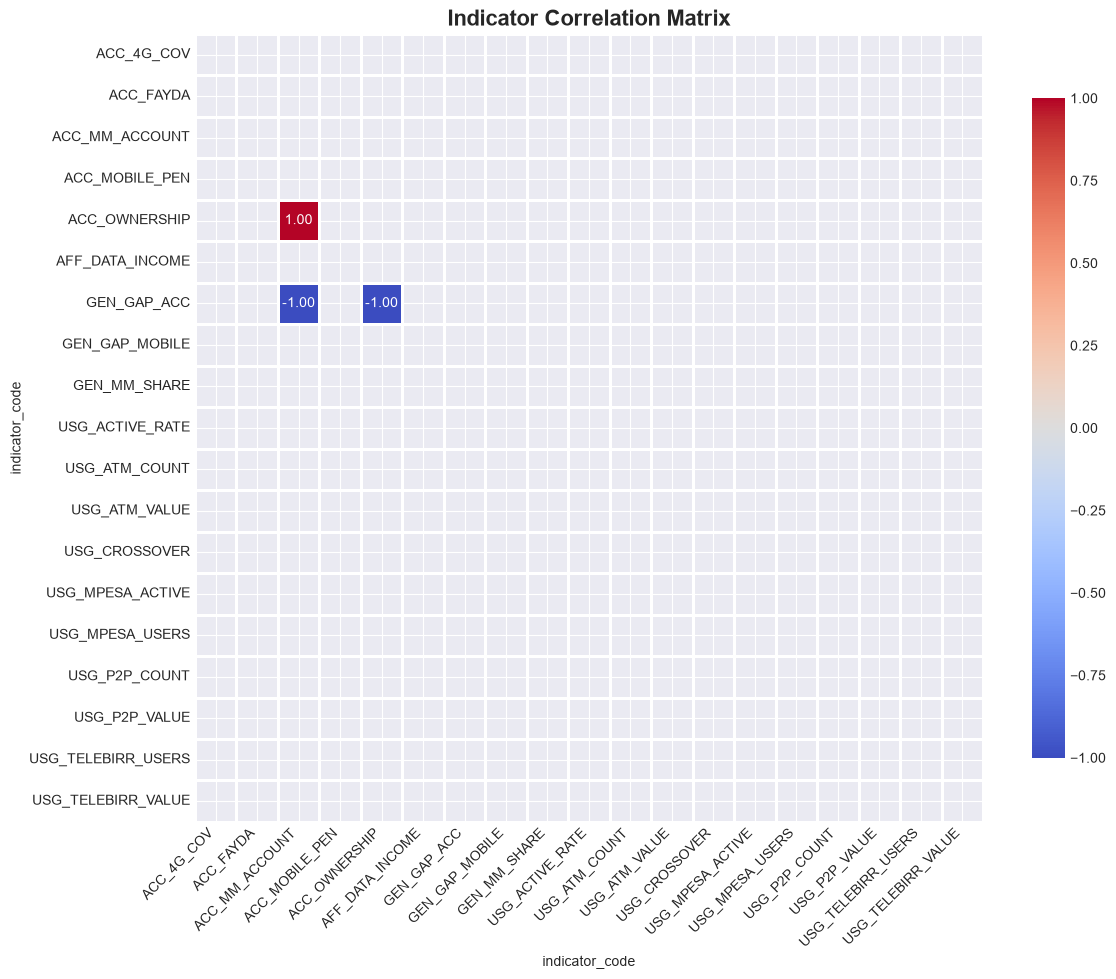


✅ Saved to: reports/figures/correlation_matrix.png

📈 Strongest correlations with Account Ownership:
   ACC_MM_ACCOUNT: 1.00
   GEN_GAP_ACC: -1.00


In [15]:
print("\n" + "="*70)
print("📊 CORRELATION ANALYSIS")
print("="*70)

# Create a pivot table for correlation analysis
# Get observation data with key indicators
obs_pivot = observations.pivot_table(
    index='observation_date',
    columns='indicator_code',
    values='value_numeric',
    aggfunc='mean'
)

print(f"\n📊 Data for correlation: {obs_pivot.shape[0]} observations, {obs_pivot.shape[1]} indicators")

if obs_pivot.shape[1] > 1:
    # Calculate correlation matrix
    corr_matrix = obs_pivot.corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Indicator Correlation Matrix', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved to: reports/figures/correlation_matrix.png")
    
    # Find strongest correlations with ACC_OWNERSHIP
    if 'ACC_OWNERSHIP' in corr_matrix.columns:
        print("\n📈 Strongest correlations with Account Ownership:")
        correlations = corr_matrix['ACC_OWNERSHIP'].sort_values(ascending=False)
        for ind, corr in correlations.items():
            if ind != 'ACC_OWNERSHIP' and not pd.isna(corr):
                print(f"   {ind}: {corr:.2f}")
else:
    print("⚠️ Not enough indicators for correlation analysis")

In [16]:
print("\n" + "="*70)
print("🔍 KEY INSIGHTS SUMMARY")
print("="*70)

insights = []

# 1. Account ownership trend
if len(acc_data) > 0:
    first_val = acc_data.iloc[0]['value_numeric']
    last_val = acc_data.iloc[-1]['value_numeric']
    total_growth = last_val - first_val
    years = acc_data.iloc[-1]['date'].year - acc_data.iloc[0]['date'].year
    avg_growth = total_growth / years
    insights.append(f"Account ownership grew from {first_val:.0f}% to {last_val:.0f}% between {acc_data.iloc[0]['date'].year} and {acc_data.iloc[-1]['date'].year} (+{total_growth:.0f}pp, {avg_growth:.1f} pp/year)")

# 2. Mobile money growth
if len(mm_data) > 0:
    first_mm = mm_data.iloc[0]['value_numeric']
    last_mm = mm_data.iloc[-1]['value_numeric']
    mm_growth = last_mm - first_mm
    insights.append(f"Mobile money penetration grew from {first_mm:.2f}% to {last_mm:.2f}% between {mm_data.iloc[0]['date'].year} and {mm_data.iloc[-1]['date'].year} (+{mm_growth:.2f}pp)")

# 3. Events analysis
if len(events) > 0:
    product_launches = len(events[events['category'] == 'product_launch'])
    policies = len(events[events['category'] == 'policy'])
    insights.append(f"Key events: {product_launches} product launches, {policies} policy changes documented")

# 4. Data quality
high_conf = len(df[df['confidence'] == 'high'])
insights.append(f"Data quality: {high_conf}/{len(df)} records ({high_conf/len(df)*100:.0f}%) have high confidence")

# 5. Gender gap
if len(gender_gap) > 0:
    latest_gap = gender_gap.iloc[-1]['value_numeric']
    insights.append(f"Gender gap in account ownership: {latest_gap:.1f}% (women lag behind men)")

print("\n📊 Top 5 Key Insights:")
for i, insight in enumerate(insights[:5], 1):
    print(f"\n{i}. {insight}")


🔍 KEY INSIGHTS SUMMARY

📊 Top 5 Key Insights:

1. Account ownership grew from 22% to 49% between 2014 and 2024 (+27pp, 2.7 pp/year)

2. Mobile money penetration grew from 4.70% to 9.45% between 2021 and 2024 (+4.75pp)

3. Key events: 2 product launches, 2 policy changes documented

4. Data quality: 41/45 records (91%) have high confidence

5. Gender gap in account ownership: 18.0% (women lag behind men)


In [17]:
# Create a summary DataFrame for reporting
summary_data = {
    'Metric': [],
    'Value': [],
    'Year': []
}

# Account ownership
if len(acc_data) > 0:
    latest_acc = acc_data.iloc[-1]
    summary_data['Metric'].append('Account Ownership Rate')
    summary_data['Value'].append(f"{latest_acc['value_numeric']:.1f}%")
    summary_data['Year'].append(latest_acc['date'].year)

# Mobile money
if len(mm_data) > 0:
    latest_mm = mm_data.iloc[-1]
    summary_data['Metric'].append('Mobile Money Penetration')
    summary_data['Value'].append(f"{latest_mm['value_numeric']:.2f}%")
    summary_data['Year'].append(latest_mm['date'].year)

# Total events
summary_data['Metric'].append('Total Events')
summary_data['Value'].append(str(len(events)))
summary_data['Year'].append('-')

# Total observations
summary_data['Metric'].append('Data Points')
summary_data['Value'].append(str(len(observations)))
summary_data['Year'].append('-')

summary_df = pd.DataFrame(summary_data)

print("\n📊 Quick Summary Table:")
display(summary_df)


📊 Quick Summary Table:


,Metric,Value,Year
0,Account Ownership Rate,49.0%,2024
1,Mobile Money Penetration,9.45%,2024
2,Total Events,10,-
3,Data Points,31,-
